In [25]:
# Making the Simplest N-Gram Model
# Libraries 
import spacy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
import warnings 
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)  # Suppress only UserWarnings
warnings.filterwarnings("ignore", category=FutureWarning)  # Suppress FutureWarnings

In [9]:
# Load SpaCy's small english model
nlp = spacy.load("en_core_web_sm")

Enter your text (press Enter twice to finish):


 My name is Manmeet Kaur.
 I have learnt french, but i continue still learning french.
 French is not a tough language, as any language needs practice and persistence.
 I also need to practice more french in my free time.
 i have to work hard to learn french as soon as possible.
 


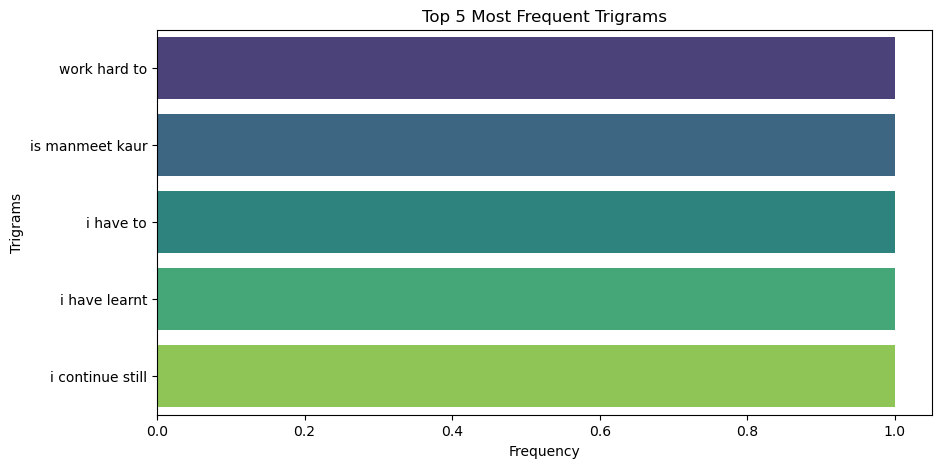

In [34]:
# Custom tokenizer function using spaCy
def tokenizer(text):
    doc = nlp(text)
    return [token.text.lower() for token in doc if not token.is_punct]

# Initialize CountVectorizer for trigrams
vectorizer = CountVectorizer(tokenizer=tokenizer, ngram_range=(3, 3))

# Ask for user input (multiple sentences)
print("Enter your text (press Enter twice to finish):")
user_input = []
while True:
    line = input()
    if line == "":  # Stop input when user presses Enter twice
        break
    user_input.append(line)

# Convert input into a list of sentences
documents = user_input

# Fit and transform the text data
X = vectorizer.fit_transform(documents)

# Convert to an array
X_array = X.toarray()

# Get n-gram feature names
ngrams = vectorizer.get_feature_names_out()

# Sum occurrences across all documents
ngram_frequencies = np.sum(X_array, axis=0)

# Get the top 5 trigrams (sorted by frequency)
sorted_indices = np.argsort(ngram_frequencies)[::-1][:5]  # Sort and get top 5
top_5_ngrams = [ngrams[i] for i in sorted_indices]
top_5_frequencies = [ngram_frequencies[i] for i in sorted_indices]


# Plot the top 5 trigrams
plt.figure(figsize=(10, 5))
sns.barplot(x=top_5_frequencies, y=top_5_ngrams, palette="viridis")
plt.xlabel("Frequency")
plt.ylabel("Trigrams")
plt.title("Top 5 Most Frequent Trigrams")
plt.show()